In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Lab 9 - Multi-layer Perceptron Forward Pass & Backpropagation

## Part I
For this exercise you will implement a simple 2-layer perceptron with the forward pass and the backpropagation to learn the weights

For the first part you'll build and train a 2-layer neural network that predicts the prices of houses, using the usual Boston housing dataset.

In [37]:
boston = pd.read_csv("../data/housing.csv")
boston

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.000000,0.165514,0.067815,0.0,0.273696,0.455845,0.495675,0.238389,0.000000,0.188979,0.252496,0.693147,0.085884,3.218876
1,0.000236,0.000000,0.242302,0.0,0.159428,0.436962,0.578128,0.299335,0.042560,0.099811,0.440312,0.693147,0.186040,3.117950
2,0.000236,0.000000,0.242302,0.0,0.159428,0.527320,0.469617,0.299335,0.042560,0.099811,0.440312,0.688003,0.061533,3.575151
3,0.000293,0.000000,0.063050,0.0,0.139941,0.505947,0.365901,0.370559,0.083382,0.064658,0.500130,0.690281,0.032843,3.538057
4,0.000705,0.000000,0.063050,0.0,0.139941,0.523014,0.424170,0.370559,0.083382,0.064658,0.500130,0.693147,0.094708,3.616309
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.000633,0.000000,0.420455,0.0,0.327021,0.458029,0.519848,0.115711,0.000000,0.151967,0.638489,0.686938,0.198109,3.152736
502,0.000438,0.000000,0.420455,0.0,0.327021,0.398993,0.565337,0.100111,0.000000,0.151967,0.638489,0.693147,0.184664,3.072693
503,0.000612,0.000000,0.420455,0.0,0.327021,0.503402,0.645695,0.090189,0.000000,0.151967,0.638489,0.693147,0.102459,3.214868
504,0.001160,0.000000,0.420455,0.0,0.327021,0.482097,0.636473,0.108419,0.000000,0.151967,0.638489,0.688788,0.123165,3.135494


In [38]:
boston.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [39]:
boston.isna().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

As usual, consider the MEDV as your target variable. 
* Split the data into training, validation and testing (70,15,15)%
* Experiment with different number of neurons per layer for your network, using the validation set

In [40]:
# your code goes here
X = boston.drop(columns=['MEDV']).values
y = boston['MEDV'].values.reshape(-1, 1)

rs = 42
X_train, X_aux, y_train, y_aux = train_test_split(X, y, train_size=0.7, random_state=rs)
X_val, X_test, y_val, y_test = train_test_split(X_aux, y_aux, train_size=0.5, random_state=rs)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (506, 13)
y shape: (506, 1)


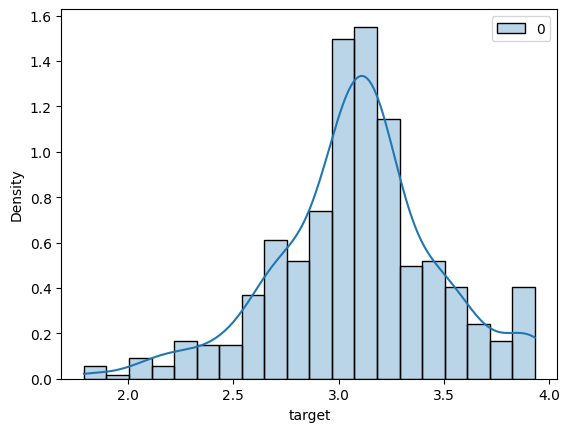

In [41]:
bins = 10 * int(y.max() - y.min()) 

sns.histplot(y, bins=bins, kde=True, alpha=0.3, stat='density')
plt.xlabel('target')
plt.show()

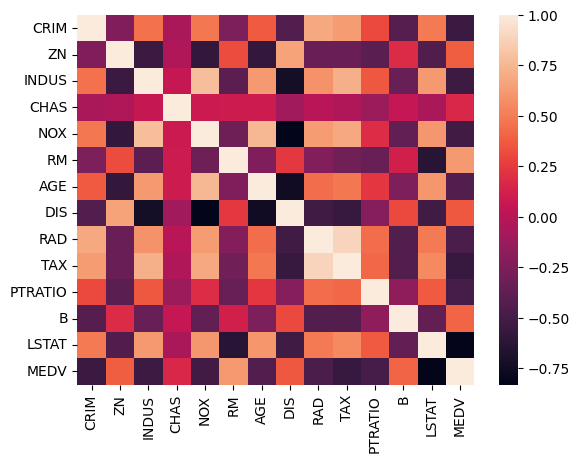

In [42]:
corr_mtrx = boston.corr().round(2)
sns.heatmap(corr_mtrx)
plt.show()

In [43]:
def sigmoid_activation(z):
    # your code goes here
    z = np.clip(z, -500, 500)
    return 1/(1+np.exp(-z))

def sigmoid_derivative(z):
    x = sigmoid_activation(z)
    return x * (1 - x)

def soft_max(z):
    z_max = np.max(z, axis=1, keepdims=True)
    z_exp = np.exp(z - z_max) # estabilidade numérica
    return z_exp / np.sum(z_exp, axis=1, keepdims=True)

def RMSE(y_true, y_pred):
    return np.mean((y_pred - y_true) ** 2) ** (1/2)

def MSE_decay(y_true, y_pred, decay_l1=0, decay_l2=0, Ws=[]):
    loss = np.mean((y_pred - y_true) ** 2)
    
    for w in Ws:
        loss += decay_l1 * np.sum(np.abs(w[:, 1:]))
        loss += decay_l2 * (np.sum(w[:, 1:] ** 2) ** (1/2))

    return loss

def CCE(y_true, y_pred):
    y_clip = np.clip(y_pred, 1e-8, 1)
    loss = y_true * np.log(y_clip)
    loss = np.sum(loss, axis=0)
    return (-1) * np.mean(loss)

class two_layer_perceptron:
    def __init__(self, dim_hidden, hdd_act, hdd_act_dx, out_act=(lambda x: x), out_act_dx=(lambda x: np.ones(x.shape)), regression=True):
        self.dim_hidden = dim_hidden
        self.hdd_act = hdd_act
        self.hdd_act_dx = hdd_act_dx
        self.out_act = out_act
        self.out_act_dx = out_act_dx
        self.hist = []
        self.epoch = 0
        self.regression = regression

        if (regression):    self.err_func = RMSE
        else:               self.err_func = CCE

    def fit(self, X, y, random_state=None):
        # normalização das features
        self.X_raw = X
        self.X_avg = self.X_raw.mean(axis=0, keepdims=True)
        self.X_std = self.X_raw.std(axis=0, keepdims=True) + 1e-8
        self.X_train = (self.X_raw - self.X_avg) / self.X_std
        self.X_train = np.hstack([np.ones((self.X_train.shape[0], 1)), self.X_train])

        # normalização das saídas
        self.y_raw = y if len(y.shape) > 1 else y.reshape(-1, 1)
        if self.regression:
            self.y_avg = self.y_raw.mean(axis=0, keepdims=True)
            self.y_std = self.y_raw.std(axis=0, keepdims=True) + 1e-8
        else:
            self.y_avg = 0
            self.y_std = 1
        self.y_train = (self.y_raw - self.y_avg) / self.y_std
        
        #  pesos aleatórios iniciais:
        self.dim_input = X.shape[1]
        self.dim_output = y.shape[1] if len(y.shape) != 1 else 1

        # random state para permitir reprodução dos resultados:
        rs = np.random.RandomState(random_state)

        # pesos do primeiro nível:
        self.W1 = rs.normal(0, np.sqrt(1 / self.dim_input), (self.dim_hidden, self.dim_input + 1))
        # self.b1 = rs.normal(0, 1, (1, self.dim_hidden))

        # pesos do segundo nível:
        self.W2 = rs.normal(0, np.sqrt(1 / self.dim_hidden), (self.dim_output, self.dim_hidden + 1))
        # self.b2 = rs.normal(0, 1, (1, self.dim_output))

    def _back_prop(self, X, y, b_size, lr, decay_l1, decay_l2):
        # X_train já possui coluna de bias
        a1 = X @ self.W1.T # + self.b1
        z1 = self.hdd_act(a1)
        z1 = np.hstack([np.ones((b_size, 1)), z1])
        a2 = z1 @ self.W2.T # + self.b2
        z2 = self.out_act(a2)

        # calculando a última passagem:
        # sem função de ativação na saída pois é regressão
        delta_output = (z2 - y) * self.out_act_dx(a2) 
        grad_W2 = delta_output.T @ z1
        grad_W2 /= b_size
        grad_W2[:, 1:] += decay_l1 * np.sign(self.W2[:, 1:]) + decay_l2 * self.W2[:, 1:]

        # # calculando a primeira passagem:
        delta_hidden = (delta_output @ self.W2[:, 1:])
        delta_hidden *= self.hdd_act_dx(a1)
        grad_W1 = delta_hidden.T @ X
        grad_W1 /= b_size
        grad_W1[:, 1:] += decay_l1 * np.sign(self.W1[:, 1:]) + decay_l2 * self.W1[:, 1:]

        # # os bias são equivalentes a multiplicar um parâmetro por um nó de valor 1
        # grad_b1 = delta_hidden.sum(axis=0, keepdims=True) / b_size
        # grad_b2 = delta_output.sum(axis=0, keepdims=True) / b_size

        self.W1 -= lr * grad_W1
        self.W2 -= lr * grad_W2
        
        # self.b1 -= lr * grad_b1 
        # self.b2 -= lr * grad_b2 

    def train(self, epochs=1e4, lr=1e-3, decay_l1=0, decay_l2=0, track_loss=False, 
              X_val = None, y_val = None, early_stop=False, tolerance = 100, b_size=None):
        
        validation = False
        if (isinstance(X_val, np.ndarray) and isinstance(y_val, np.ndarray)):
            counter = 0
            best_w = (self.W1.copy(), self.W2.copy())
            best_l = np.inf
            validation = True
            yv = y_val if len(y_val.shape) > 1 else y_val.reshape(-1, 1)
            
        if b_size is None or b_size > self.X_train.shape[0]:
            b_size = self.X_train.shape[0]

        self.hist = []

        for epoch in range(int(epochs)):
            for start in range(0, self.X_train.shape[0], b_size):
                end = min(start + b_size, self.X_train.shape[0])
                self._back_prop(self.X_train[start:end, :], self.y_train[start:end, :], end-start, lr, decay_l1, decay_l2)

            if track_loss:
                y_pred = self.predict(self.X_raw)
                loss_t = self.err_func(self.y_raw, y_pred)
                self.hist.append({'dataset': 'training',
                                  'epoch': epoch,
                                  'nodes': self.dim_hidden,
                                  'loss': loss_t})

                if (validation):
                    y_pred = self.predict(X_val)
                    loss_v = self.err_func(yv, y_pred)
                    self.hist.append({'dataset': 'validation',
                                      'epoch': epoch,
                                      'nodes': self.dim_hidden,
                                      'loss': loss_v})
                
            if (early_stop and validation):
                y_pred = self.predict(X_val)
                loss = self.err_func(yv, y_pred)

                if (loss < best_l): 
                    best_l = loss
                    best_w = self.W1.copy(), self.W2.copy()#, self.b1.copy(), self.b2.copy()
                    counter = 0
                    self.epoch = epoch

                elif (counter < tolerance):
                    counter += 1

                else:
                    # self.W1, self.W2, self.b1, self.b2 = best_w
                    self.W1, self.W2 = best_w
                    return
        self.epoch = epochs-1

    def predict(self, X): 
        if (len(X.shape) == 1): X_pred = X.reshape(1, -1)
        else:                   X_pred = X

        # normalizando as features conforme os dados de treino
        X_pred = (X_pred - self.X_avg) / self.X_std

        # forward propagation
        X_pred = np.hstack([np.ones((X_pred.shape[0], 1)), X_pred])
        a1 = X_pred @ self.W1.T # + self.b1
        z1 = self.hdd_act(a1)
        z1 = np.hstack([np.ones((X_pred.shape[0], 1)), z1])
        a2 = z1 @ self.W2.T # + self.b2
        z2 = self.out_act(a2)

        if self.regression:
            return z2 * self.y_std + self.y_avg
        else:
            return z2

In [46]:
# cfg

lr = 1e-3
ep = 1e4
tol = 1e3
dim = 32
l2 = 1e-2
es = True


In [47]:
nn = two_layer_perceptron(dim, sigmoid_activation, sigmoid_derivative)
nn.fit(X_train, y_train, random_state=rs)
nn.train(track_loss=True, tolerance=tol, epochs=ep, lr=lr, X_val=X_val, y_val=y_val, decay_l2=l2, early_stop=es)

validation RMSE:  0.17185322954730847


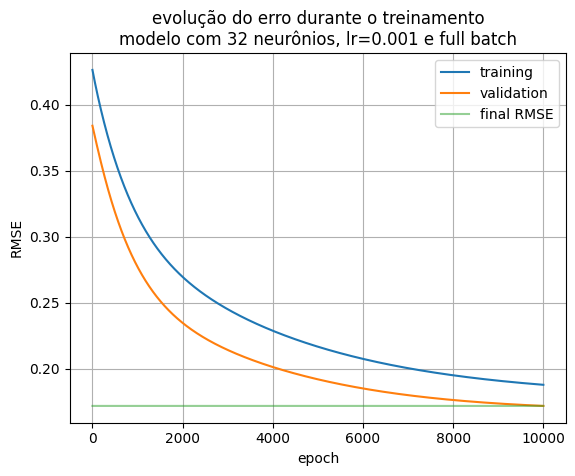

In [48]:
y_pred = nn.predict(X_val) 
final_rmse = RMSE(y_val.reshape(-1, 1), y_pred)
print('validation RMSE: ', final_rmse)

sns.lineplot(pd.DataFrame(nn.hist), x='epoch', y='loss', hue='dataset')
sns.lineplot(x=np.arange(int(nn.epoch)), y=np.ones(int(nn.epoch))*final_rmse, label='final RMSE', alpha=0.5)
plt.title(f'evolução do erro durante o treinamento\nmodelo com {nn.dim_hidden} neurônios, lr={lr} e full batch')
plt.ylabel('RMSE')
plt.xlabel('epoch')
plt.grid(True)
plt.show()

In [68]:
final_hist = []
full_batch = X_train.shape[0]
bs = [int(full_batch/(2**i)) for i in range(4, -1, -1)]
bs = [1] + bs
dims = [2**i for i in range(1, 7)]
lr = 1e-2
max_ep = 1e5

for b in bs:
    for dim in dims:
        nn = two_layer_perceptron(dim, sigmoid_activation, sigmoid_derivative)
        nn.fit(X_train, y_train, random_state=rs)
        nn.train(X_val=X_val, y_val=y_val, early_stop=True, lr=lr, b_size=b, epochs=max_ep)

        loss_v = RMSE(y_val, nn.predict(X_val))
        final_hist.append({'RMSE': loss_v, 'dataset': 'validation', 'epoch': nn.epoch, 'nodes': dim, 'b_size': b})
        
        print(f'nós: {dim:03d} | epoch: {int(nn.epoch):06d} | val loss: {loss_v:.6f} | b_size: {b:03d}')


nós: 002 | epoch: 000022 | val loss: 0.272413 | b_size: 001
nós: 004 | epoch: 000023 | val loss: 0.239641 | b_size: 001
nós: 008 | epoch: 000029 | val loss: 0.179198 | b_size: 001
nós: 016 | epoch: 000058 | val loss: 0.138984 | b_size: 001
nós: 032 | epoch: 000126 | val loss: 0.117725 | b_size: 001
nós: 064 | epoch: 000057 | val loss: 0.108895 | b_size: 001
nós: 002 | epoch: 002321 | val loss: 0.271241 | b_size: 078
nós: 004 | epoch: 002255 | val loss: 0.238389 | b_size: 078
nós: 008 | epoch: 002641 | val loss: 0.168762 | b_size: 078
nós: 016 | epoch: 002090 | val loss: 0.140906 | b_size: 078
nós: 032 | epoch: 006501 | val loss: 0.124243 | b_size: 078
nós: 064 | epoch: 004534 | val loss: 0.107585 | b_size: 078
nós: 002 | epoch: 003401 | val loss: 0.267852 | b_size: 157
nós: 004 | epoch: 004974 | val loss: 0.239960 | b_size: 157
nós: 008 | epoch: 005388 | val loss: 0.172335 | b_size: 157
nós: 016 | epoch: 011115 | val loss: 0.135404 | b_size: 157
nós: 032 | epoch: 014819 | val loss: 0.1

In [69]:
final_hist = pd.DataFrame(final_hist)
# final_hist.to_csv('grid_search.csv')
# final_hist = pd.DataFrame(final_hist)

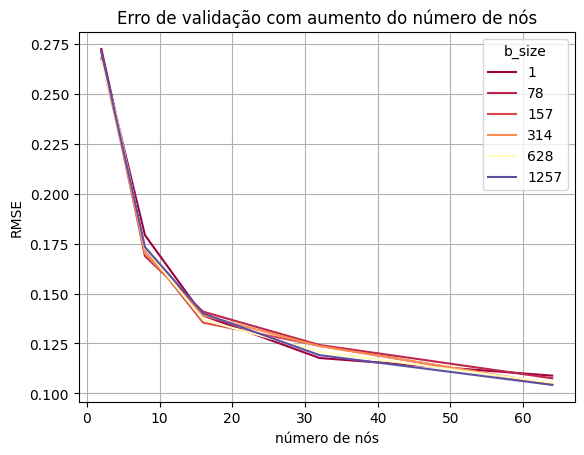

In [70]:
sns.lineplot(final_hist, x='nodes', y='RMSE', hue='b_size', palette='Spectral')
plt.title('Erro de validação com aumento do número de nós')
plt.xlabel('número de nós')
plt.ylabel('RMSE')
plt.grid(True)
plt.show()

In [71]:
best_setup = final_hist.loc[final_hist['RMSE'].idxmin()]
best_setup

RMSE         0.104252
dataset    validation
epoch         99999.0
nodes              64
b_size           1257
Name: 35, dtype: object

In [72]:
X_train_val = np.concat((X_train, X_val), axis=0)
y_train_val = np.concat((y_train, y_val), axis=0)

In [ ]:
nn = two_layer_perceptron(best_setup['nodes'], sigmoid_activation, sigmoid_derivative)
nn.fit(X_train_val, y_train_val, random_state=rs)
nn.train(epochs=best_setup['epoch'], b_size=best_setup['b_size'], lr=lr, X_val=X_test, y_val=y_test, track_loss=True)

In [ ]:
pd.DataFrame(nn.hist)

,dataset,epoch,nodes,loss
0,training,0,16,0.210562
1,validation,0,16,0.227717
2,training,1,16,0.186347
3,validation,1,16,0.205761
4,training,2,16,0.179012
...,...,...,...,...
717,validation,358,16,0.159789
718,training,359,16,0.104810
719,validation,359,16,0.159842
720,training,360,16,0.104747


Test RMSE:  0.15989414372755034


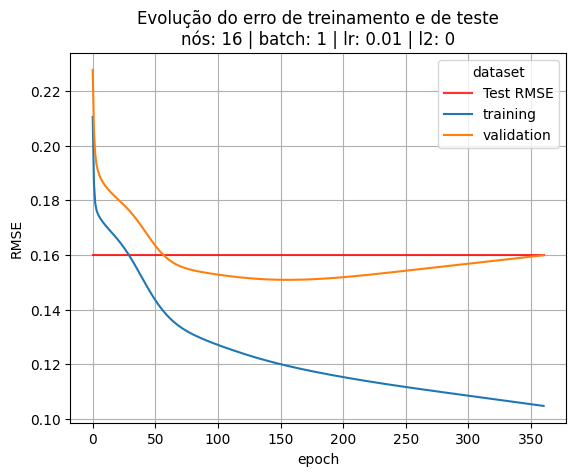

In [ ]:
y_pred = nn.predict(X_test)
test_rmse = RMSE(y_test, y_pred)
print('Test RMSE: ', test_rmse)

ones = np.ones(int(best_setup['epoch']))
ran = np.arange(int(best_setup['epoch']))
sns.lineplot(x=ran, y=ones*test_rmse, label='Test RMSE', alpha=0.8, color='red')
sns.lineplot(pd.DataFrame(nn.hist), x='epoch', y='loss', hue='dataset')

plt.ylabel('RMSE')
plt.xlabel('epoch')
plt.title(f'Evolução do erro de treinamento e de teste\nnós: {best_setup['nodes']} | batch: {best_setup['b_size']} | lr: {lr} | l2: 0')
plt.grid(True)
plt.show()

## Part II 

For this exercise you will build and train a 2-layer neural network that predicts the exact digit from a hand-written image, using the MNIST dataset. 
For this exercise, add weight decay to your network.

In [ ]:
from sklearn.datasets import load_digits

In [ ]:
digits = load_digits()

In [ ]:
X = digits.data
y = digits.target

In [ ]:
print('X shape: ', X.shape)
print('y shape: ', y.shape)

X shape:  (1797, 64)
y shape:  (1797,)


In [ ]:
y_dummy = pd.get_dummies(y, dtype=int).values
print(y_dummy.shape)
y_dummy

(1797, 10)


array([[1, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 1, 0]], shape=(1797, 10))

In [ ]:
X_train, X_aux, y_train, y_aux = train_test_split(X, y_dummy, test_size=0.3)
X_val, X_test, y_val, y_test = train_test_split(X_aux, y_aux, test_size=0.5)

In [ ]:
# cfg

lr = 1e-2
ep = 1e4
tol = 1e3
dim = 16
l2 = 1e-4
es = True

In [ ]:
nn = two_layer_perceptron(25, sigmoid_activation, sigmoid_derivative, soft_max, regression=False)
nn.fit(X_train, y_train, random_state=rs)
nn.train(ep, lr, decay_l2=l2, tolerance=tol, early_stop=es, track_loss=True, X_val=X_val, y_val=y_val)

KeyboardInterrupt: 

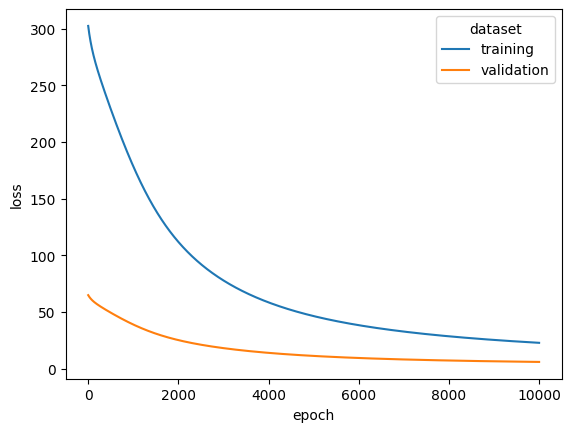

In [ ]:
sns.lineplot(pd.DataFrame(nn.hist), x='epoch', y='loss', hue='dataset')
plt.show()

In [ ]:
y_pred = nn.predict(X_test)
print('fina loss: ', CCE(y_test, y_pred))

fina loss:  5.683734369152022


In [ ]:
print(y_pred.shape)
df_pred = pd.DataFrame(y_pred)
df_pred

(270, 10)


,0,1,2,3,4,5,6,7,8,9
0,0.001523,0.041892,0.002473,0.002088,0.028563,0.003034,0.909391,0.001020,0.009779,0.000237
1,0.000208,0.000659,0.004889,0.967978,0.000011,0.002064,0.000110,0.000658,0.006719,0.016704
2,0.000539,0.859529,0.027640,0.001449,0.020214,0.000556,0.007630,0.022410,0.058895,0.001138
3,0.000444,0.000687,0.002906,0.004916,0.000274,0.984987,0.000813,0.001177,0.002828,0.000970
4,0.014249,0.008686,0.022476,0.548371,0.001641,0.138462,0.024646,0.001952,0.026246,0.213271
...,...,...,...,...,...,...,...,...,...,...
265,0.000671,0.746918,0.016297,0.002090,0.033353,0.000184,0.001019,0.097927,0.093227,0.008313
266,0.000372,0.003846,0.032414,0.945469,0.000032,0.006795,0.000104,0.001507,0.003688,0.005774
267,0.001743,0.001896,0.014205,0.838845,0.000044,0.012086,0.000295,0.007376,0.041500,0.082010
268,0.943255,0.000154,0.001051,0.002794,0.008156,0.016980,0.010369,0.003200,0.003059,0.010983


In [ ]:
df_pred.max(axis=1)

0      0.909391
1      0.967978
2      0.859529
3      0.984987
4      0.548371
         ...   
265    0.746918
266    0.945469
267    0.838845
268    0.943255
269    0.545542
Length: 270, dtype: float64

In [ ]:
np.mean(np.argmax(y_pred, axis=1) == np.argmax(y_val, axis=1))

np.float64(0.09259259259259259)

Again, you will split the data into training, validation and testing.